#**Bibliotecas Necessárias**

In [2]:
!pip install --upgrade ultralytics                                # Atualiza e instala a versão mais recente da biblioteca "ultralytics"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.6 MB/s eta 0:00:00


In [3]:
!pip install retina-face --upgrade                          # Atualiza e instala a versão mais recente da biblioteca "retina-face"

In [4]:
!pip install facenet-pytorch --no-deps                            # Instala a biblioteca "facenet-pytorch", que contém modelos pré-treinados (MTCNN)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.1 MB/s eta 0:00:00


In [5]:
import torch  # Para MTCNN (uso de GPU)
from PIL import Image # NECESSÁRIO para a função detectar_com_mtcnn (para abrir a imagem)


# --- Bibliotecas de Avaliação ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import numpy as np
from ultralytics import YOLO
from facenet_pytorch import MTCNN
import torch
from retinaface import RetinaFace                                                     # Importa a classe principal para detecção facial
import cv2                                                                            # Importa o OpenCV (cv2) para manipulação de imagens
import seaborn as sns

# --- Bibliotecas de Utilidade e Salvar Falhas
import os
import shutil
import zipfile

from google.colab import files
import matplotlib.pyplot as plt
import glob
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **Base de Dados**

**Download pelo Google Drive**

In [ ]:
# !pip install gdown

# folder_id = '18EyoilzUysYp80kANnTTXSzaUlIv9cr8'
# !gdown --folder --id {folder_id} -O /content


**Download pelo GitHub**

In [ ]:
# Clona o repo (leve)
!git clone --filter=blob:none --no-checkout https://github.com/Gusnet007/Comparacao-de-modelos-reconhecimento-Facial-TCC.git

# Entra no diretório do repositório clonado
%cd /content/Comparacao-de-modelos-reconhecimento-Facial-TCC

# Sparse checkout
!git sparse-checkout init --cone
!git sparse-checkout set datasets/

# Checkout do commit
!git checkout 3490f1127d944756f99ce6a622ffb70867cc5c52

# Ver o que veio em datasets
!ls -la datasets


fatal: destination path 'Comparacao-de-modelos-reconhecimento-Facial-TCC' already exists and is not an empty directory.
/content/Comparacao-de-modelos-reconhecimento-Facial-TCC
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 1.45 KiB | 1.45 MiB/s, done.
Filtering content: 100% (4/4), 941.31 MiB | 41.53 MiB/s, done.
Note: switching to '3490f1127d944756f99ce6a622ffb70867cc5c52'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -


In [ ]:
# Mostra todos os zips dentro de datasets (inclui subpastas)
!find datasets -type f -name "*.zip" -print

# Move todos os zips encontrados para /content
!find datasets -type f -name "*.zip" -exec mv -t /content {} +

# Confere
!ls -la /content/*.zip 2>/dev/null || echo "Nenhum .zip encontrado."


datasets/LFW_subset.zip
datasets/CelebA_subset.zip
datasets/UTKFace_subset.zip
datasets/WIDER_subset.zip
-rw-r--r-- 1 root root  35453411 Dec 18 14:41 /content/CelebA_subset.zip
-rw-r--r-- 1 root root  44730140 Dec 18 14:41 /content/LFW_subset.zip
-rw-r--r-- 1 root root 326763893 Dec 18 14:41 /content/UTKFace_subset.zip
-rw-r--r-- 1 root root 580082682 Dec 18 14:41 /content/WIDER_subset.zip


**Extração e eciração das pastas dentro do Content**

In [ ]:
!unzip -q "/content/CelebA_subset.zip" -d "/content/CelebA_subset"              # Descompacta o arquivo CelebA_subset.zip no diretório correspondente
!unzip -q "/content/LFW_subset.zip" -d "/content/LFW_subset"                    # Descompacta o arquivo LFW_subset.zip no diretório correspondente
!unzip -q "/content/UTKFace_subset.zip" -d "/content/UTKFace_subset"            # Descompacta o arquivo UTKFace_subset.zip no diretório correspondente
!unzip -q "/content/WIDER_subset.zip" -d "/content/WIDER_subset"                # Descompacta o arquivo WIDER_subset.zip no diretório correspondente

**Bases de dados**

In [ ]:
# cada base de dados em uma variavel
base1_imgs = glob.glob('/content/CelebA_subset/**/*.jpg', recursive=True)
base2_imgs = glob.glob('/content//LFW_subset/**/*.jpg', recursive=True)
base3_imgs = glob.glob('/content/UTKFace_subset/**/*.jpg', recursive=True)
base4_imgs = glob.glob('/content/WIDER_subset/**/*.jpg', recursive=True)

# Junta as 4 em uma só
all_imgs = base1_imgs + base2_imgs + base3_imgs + base4_imgs
print("Total de imagens:", len(all_imgs ))

Total de imagens: 20000


# **Funções de detecção e avaliação**

**YOLOv8 – Detecção**

In [14]:
model_yolo = YOLO('yolov8n.pt')                                                       # Carrega um modelo YOLOv8 pré-treinado

def detectar_com_yolo(path_img):
    try:
                                                                                      # 1. Executa a detecção na imagem fornecida.
        result = model_yolo(path_img, verbose=False)                                  # model_yolo(path_img) retorna uma lista de objetos 'Result' (geralmente um para cada imagem processada)

        boxes = result[0].boxes                                                       # 2. Acessa as bounding boxes da primeira imagem processada.

                                                                                      # 3. Verifica se alguma caixa delimitadora foi detectada.
        return boxes is not None and len(boxes) > 0                                                        # len(boxes) retorna o número de objetos detectados.
                                                                                      # Se for maior que 0, significa que objetos foram encontrados.

    except Exception as e:
        print(f"[YOLOv8] Erro em {path_img}: {e}")                                    # Captura e imprime qualquer erro que possa ocorrer durante o processo
        return False                                                                  # Em caso de erro, retorna False, indicando que a detecção não foi bem-sucedida.


**MTCNN - Detecção**

In [15]:
                                                                                      # 1. Configuração do Ambiente
device = 'cuda' if torch.cuda.is_available() else 'cpu'                               # Verifica se uma GPU (CUDA) está disponível e define o dispositivo de processamento.

                                                                                      # 2. Inicialização do Modelo MTCNN
mtcnn = MTCNN(keep_all=False, device=device)                                          # Cria uma instância do MTCNN.
                                                                                      # keep_all=False: Indica que apenas a face com maior probabilidade será retornada.


def detectar_com_mtcnn(path_img):
    try:
                                                                                      # 3. Pré-processamento da Imagem
                                                                                      # Abre a imagem no caminho fornecido.
        img = Image.open(path_img).convert('RGB')                                     # .convert('RGB'): Garante que a imagem está no formato de cores RGB.


                                                                                      # 4. Execução do MTCNN
        face = mtcnn(img)                                                             # O objeto mtcnn é chamado como uma função, executando o pipeline de detecção facial.
                                                                                      # Ele retorna PyTorch que contém a face detectada (ou None se nenhuma face for encontrada).


        return face is not None                                                       # 5. Verificação do Resultado
                                                                                      # Retorna True se o MTCNN retornou um tensor (ou seja, detectou uma face).
                                                                                      # Retorna False se o valor for None (ou seja, nenhuma face detectada).


    except Exception as e:
        print(f"[MTCNN] Erro em {path_img}: {e}")                                     # Captura e imprime qualquer erro que possa ocorrer
        return False                                                                  # Em caso de erro, retorna False.


**RetinaFace - Detecção**

In [16]:
def detectar_com_retinaface(path_img):
    detections = None
    try:
                                                                                      # 1. Carregamento da Imagem
        img = cv2.imread(path_img)                                                    # cv2.imread lê a imagem do caminho especificado.
                                                                                      # O OpenCV carrega a imagem como um array NumPy (BGR).

                                                                                      # 2. Verificação de Carregamento
        if img is None:                                                               # Verifica se a imagem foi carregada corretamente. Se 'img' for None, houve um erro
            print(f"[RetinaFace] Erro: não conseguiu carregar {path_img}")
            return False

                                                                                      # 3. Detecção de Rostos
        detections = RetinaFace.detect_faces(img)                                     # O método detect_faces executa a inferência do modelo RetinaFace na imagem.

                                                                                      # 4. Verificação do Resultado
        return detections is not None and len(detections) > 0                         # Verifica se 'detections' não é None (indicando que o processo de detecção ocorreu)
                                                                                      # E se o comprimento do dicionário de detecções é maior que zero (ou seja, há faces detectadas).
    except Exception as e:
        print(f"[RetinaFace] Erro em {path_img}: {e}")                                # Captura e imprime qualquer erro inesperado durante a execução da função.
        return False                                                                  # Em caso de erro, retorna False.


**Função de Avaliação**

In [17]:
def avaliar_modelo(imagens, funcao_modelo, nome_modelo):                              # Avalia o desempenho de um modelo de detecção facial em um conjunto de imagens.

    print(f"\n🔎 Avaliando modelo: {nome_modelo}")
    resultados = []                                                                   # Lista para armazenar o resultado booleano de cada detecção (True se detectou, False caso contrário)
    tempos = []                                                                       # Lista para armazenar o tempo de inferência de cada imagem

    for path in imagens:                                                              # Itera sobre cada imagem no conjunto de dados
        try:
            inicio = time.time()                                                      # Marca o tempo de início da detecção
            resultado = funcao_modelo(path)                                           # Executa a função de detecção do modelo na imagem
            fim = time.time()                                                         # Marca o tempo de fim da detecção

            resultados.append(resultado)                                              # Adiciona o resultado (True/False) à lista
            tempos.append(fim - inicio)                                               # Adiciona o tempo de inferência à lista

        except Exception as e:
            print(f"Erro em {path}: {e}")                                             # Em caso de erro durante a detecção de uma imagem específica, imprime o erro
            resultados.append(False)                                                  # e considera como uma falha na detecção para fins de avaliação.
            tempos.append(0)                                                          # Considera 0 tempo para imagens com erro para não distorcer a média


    y_true = [1] * len(imagens)                                                       # Prepara os rótulos verdadeiros (y_true) e as previsões (y_pred) para o cálculo das métricas
    y_pred = [1 if r else 0 for r in resultados]                                      # Converte os resultados booleanos (True/False) para inteiros (1/0) para o cálculo das métricas

                                                                                      # Calcula as métricas de avaliação do modelo
    acc = accuracy_score(y_true, y_pred)                                              # Acurácia: proporção de previsões corretas (detecções e não-detecções esperadas)
    precisao = precision_score(y_true, y_pred, zero_division=0)                       # Precisão: proporção de detecções corretas entre todas as detecções do modelo
    revocacao = recall_score(y_true, y_pred, zero_division=0)                         # Recall (sensibilidade): proporção de detecções corretas entre todas as faces reais
    f1 = f1_score(y_true, y_pred, zero_division=0)                                    # F1-Score: média harmônica da precisão e do recall
    tempo_medio = sum(tempos) / len(tempos)                                           # Tempo médio de inferência por imagem

    # Exibição dos resultados das métricas no console
    print("===== MÉTRICAS DE AVALIAÇÃO ===%%")
    print(f"   Acurácia:   {acc:.2%}")
    print(f"   Precisão:   {precisao:.2%}")
    print(f"   Recall:     {revocacao:.2%}")
    print(f"   F1-Score:   {f1:.2%}")
    print(f"   Tempo médio: {tempo_medio:.3f}s")

    print("\nMatriz de Confusão:")                                                    # Exibe a Matriz de Confusão para entender os erros e acertos do modelo
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório detalhado:")                                                   # Exibe um relatório detalhado de classificação, incluindo precisão, recall, f1-score e suporte por classe
    print(classification_report(y_true, y_pred, zero_division=1))

    # Armazena as métricas em um dicionário para retorno e comparações futuras
    metricas = {
        "modelo": nome_modelo,
        "acuracia": acc,
        "precisao": precisao,
        "recall": revocacao,
        "f1_score": f1,
        "tempo_medio": tempo_medio
    }

    return resultados, metricas                                                        # Retorna os resultados e as métricas

**Salvar imagens não detectadas**

In [18]:
def salvar_imagens_falhas(imagens, resultados, nome_modelo, pasta_base="falhas"):             # Função para salvar as imagens em que o modelo falhou na detecção. As imagens falhas são copiadas para uma pasta específica e um arquivo ZIP é gerado.

    # Garante que resultados tem o mesmo tamanho que imagens
    if len(imagens) != len(resultados):
        print(f"[ERRO] Quantidade de imagens ({len(imagens)}) != quantidade de resultados ({len(resultados)})")
        return None                                                                           # Retorna None caso a quantidade de imagens e resultados não coincida

    # Cria pasta do modelo (ex: falhas/YOLOv8_gaussiano)
    pasta_modelo = os.path.join(pasta_base, nome_modelo.replace(" ", "_").replace("/", "_"))  # Cria uma pasta para o modelo, no formato falhas/Modelo
    os.makedirs(pasta_modelo, exist_ok=True)                                                  # Cria a pasta se não existir

    qtd_falhas = 0                                                                            # Contador para o número de falhas detectadas

    # Salva somente as imagens em que o modelo FALHOU (resultado == False)
    for path_img, ok in zip(imagens, resultados):
        if not ok:                                                                            # Se o modelo falhou na detecção (resultado == False)
            # Verifica se o arquivo da imagem realmente existe
            if not os.path.isfile(path_img):
                print(f"[AVISO] Arquivo não encontrado, pulando: {path_img}")
                continue                                                                      # Pula para a próxima imagem se o arquivo não for encontrado

            nome_arquivo = os.path.basename(path_img)                                         # Extrai o nome da imagem
            destino = os.path.join(pasta_modelo, nome_arquivo)                                # Define o caminho de destino para salvar a imagem

            try:
                shutil.copy2(path_img, destino)                                               # Copia a imagem para a pasta de falhas
                qtd_falhas += 1                                                               # Incrementa o contador de falhas
            except Exception as e:
                print(f"[ERRO] Ao copiar {path_img}: {e}")                                    # Se houver erro ao copiar, exibe o erro

    # Se não teve falha, não faz ZIP
    if qtd_falhas == 0:
        print(f"[INFO] Nenhuma imagem de falha para {nome_modelo}. ZIP não será criado.")
        return None                                                                           # Retorna None caso não tenha nenhuma falha detectada

    # Cria o arquivo ZIP com as falhas
    zip_path = pasta_modelo + ".zip"                                                          # Caminho do arquivo ZIP a ser gerado
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for arquivo in os.listdir(pasta_modelo):                                              # Adiciona todas as imagens da pasta de falhas no arquivo ZIP
            caminho_completo = os.path.join(pasta_modelo, arquivo)                            # Caminho completo do arquivo
            if os.path.isfile(caminho_completo):                                              # Verifica se é um arquivo (não diretório)
                zipf.write(caminho_completo, arcname=arquivo)                                 # Adiciona o arquivo no ZIP

    # Exibe mensagens informando que o processo foi concluído com sucesso
    print(f"[OK] {qtd_falhas} imagens de falha salvas para {nome_modelo}.")
    print(f"[OK] Arquivo ZIP gerado em: {zip_path}")

    return zip_path                                                                           # Retorna o caminho do arquivo ZIP gerado

**Função da Matriz de Confusão**

In [19]:
def plotar_matrizes_comparativas(lista_resultados_metricas):                    # Gera uma única figura com as Matrizes de Confusão de múltiplos modelos.

    num_modelos = len(lista_resultados_metricas)

    fig, axes = plt.subplots(1, num_modelos, figsize=(5 * num_modelos, 4))      # Cria uma figura com subplots organizados (1 linha, N colunas)

    if num_modelos == 1:                                                        # Se houver apenas um modelo, converte 'axes' para uma lista
        axes = [axes]

    classes = ['Não Detectado (0)', 'Detectado (1)']                            # Rótulos para a Matriz de Confusão (0=Não Detectado, 1=Detectado)

    for i, (resultados, nome_modelo) in enumerate(lista_resultados_metricas):   # 1. Itera sobre os resultados de cada modelo

        # OBTENÇÃO DOS RÓTULOS
        y_true = [1] * len(resultados)
        y_pred = [1 if r else 0 for r in resultados]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])                    # 2. CALCULAR A MATRIZ; labels=[0, 1] garante a ordem correta das classes

        sns.heatmap(cm,                                                         # 3. PLOTAR NO SUBPLOT CORRESPONDENTE; Cria o heatmap no eixo 'axes[i]'
                    annot=True,                                                 # Exibe os números nas células
                    fmt='d',                                                    # Formata como inteiro
                    cmap='viridis',                                             # Um esquema de cores diferente para contraste
                    xticklabels=classes,                                        # Rótulos das previsões
                    yticklabels=classes,                                        # Rótulos verdadeiros
                    linewidths=.5,
                    linecolor='black',
                    ax=axes[i])                                                 # Especifica o subplot a ser usado

        # Adiciona títulos e rótulos
        axes[i].set_title(f'{nome_modelo}')
        axes[i].set_ylabel('Rótulo Verdadeiro')
        axes[i].set_xlabel('Rótulo Predito')

    # Ajusta o layout para evitar sobreposição
    plt.tight_layout()
    plt.show()

# **1° avaliação de imagens: analise comum - Sem ruído**

**Avaliação do Yolov8 na Base da dados sem ruído**

In [12]:
# Avalia o modelo YOLOv8 em todas as imagens, gerando métricas e resultados
resultados_yolo, metricas_yolo  = avaliar_modelo(all_imgs, detectar_com_yolo, "YOLOv8")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(all_imgs, resultados_yolo, "YOLOv8")

NameError: name 'all_imgs' is not defined

**Avaliação do MTCNN na Base da dados sem ruído**

In [ ]:
# Avalia o modelo MTCNN em todas as imagens, gerando métricas e resultados
resultados_mtcnn, metricas_MTCNN = avaliar_modelo(all_imgs, detectar_com_mtcnn, "MTCNN")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(all_imgs, resultados_mtcnn, "MTCNN")

**Avaliação do RetinaFace na Base da dados sem ruído**

In [ ]:
# Avalia o modelo RetinaFace em todas as imagens, gerando métricas e resultados
resultados_retinaface, metricas_retinaface = avaliar_modelo(all_imgs, detectar_com_retinaface, "RetinaFace")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(all_imgs, resultados_retinaface, "RetinaFace")

**Tabela de resultados com as métricas geradas**

In [ ]:
dados = {
    "YOLOv8": {
        "acuracia": 99.47,
        "precisao": 100,
        "recall": 99.47,
        "f1_score": 99.73
    },
    "MTCNN": {
        "acuracia": 98.28,
        "precisao": 100,
        "recall": 98.28,
        "f1_score": 99.13
    },
    "RetinaFace": {
        "acuracia": 98.71,
        "precisao": 100,
        "recall": 98.71,
        "f1_score": 99.35
    }
}

In [ ]:
# dados = [                                                                     # Junta todos os dicionários de métricas em uma lista
#     metricas_yolo,
#     metricas_MTCNN,
#     metricas_retinaface
# ]

df_metricas = pd.DataFrame.from_dict(dados, orient="index")                     # Converte em DataFrame
# df_metricas.set_index("modelo", inplace=True)                                 # Deixa o nome do modelo como índice

for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                   # Converte para porcentagem (exceto o tempo)
    df_metricas[coluna] = df_metricas[coluna]

display(df_metricas)                                                            # Exibe a tabela no Colab

**Salvar em CSV e JSON**

In [ ]:
# Salva em CSV
df_metricas.to_csv("metricas_deteccao_faces.csv")

# Salva em JSON
# df_metricas.to_json("metricas_deteccao_faces.json", orient="index")

**Gráfico em linha de Acurácia entre os modelos**

In [ ]:
plt.plot(df_metricas["acuracia"], marker="o", linestyle="-", color="purple")    # Plota uma linha representando a acurácia dos modelos, com marcadores circulares (“o”)
plt.title("Acurácia dos Modelos - sem ruído")                                   # Define o título do gráfico
plt.ylabel("Acurácia (%)")                                                      # Rótulo do eixo Y
plt.ylim(95, 100)                                                               # Limita o eixo Y entre 95% e 100% para dar mais destaque às diferenças

for i, v in enumerate(df_metricas["acuracia"]):                                 # Adiciona rótulos de texto próximos a cada ponto, mostrando o valor da acurácia
    plt.text(i, v - 0.3, f"{v:.2f}%", ha="center")                              # posiciona o texto levemente abaixo do ponto

plt.show()                                                                      # Exibe o gráfico na tela

**Gráfico em barra de todas as Métricas de avaliação (Acurácia, Precisão, Recall, F1-Score)**

In [ ]:
metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]            # Lista das métricas de desempenho

plt.figure(figsize=(12, 6))                                                     # Cria a figura do gráfico com tamanho definido

ax = df_metricas[metricas_desempenho].plot.bar(                                 # Gera o gráfico de barras a partir do DataFrame; Cada coluna em 'metricas_desempenho' será representada como uma barra
    figsize=(12, 6),
    rot=0,                                                                      # Mantém os rótulos do eixo x na horizontal
    title="Comparação de Métricas de Desempenho dos Modelos (em %)",
    grid=True                                                                   # Ativa a grade para facilitar a visualização
)

ax.set_title(
    "Comparação de Métricas de Desempenho dos Modelos (em %)",
    pad=20
)

for p in ax.patches:                                                            # Adiciona rótulos com os valores numéricos em cima de cada barra
    ax.annotate(f'{p.get_height():.2f}%',                                       # Valor da barra com duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',                                       # Centraliza o texto horizontal e verticalmente
                xytext=(0, 10),                                                 # Desloca o texto 10 pontos acima da barra
                textcoords='offset points',
                fontsize=7)

plt.ylim(80, 100)                                                               # Limita o eixo Y entre 80% e 100%
plt.xlabel("Modelo")                                                            # Define o rótulo do eixo X
plt.ylabel("Porcentagem (%)")                                                   # Define o rótulo do eixo Y
plt.legend(title="Métrica", loc='lower right')                                  # Exibe a legenda com título e posição definida
plt.tight_layout()
plt.show()                                                                      # Exibe o gráfico na tela

In [ ]:
import matplotlib.pyplot as plt

metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]

ax = df_metricas[metricas_desempenho].plot.barh(
    figsize=(12, 6),
    title="Comparação de Métricas de Desempenho dos Modelos (em %)",
    grid=True
)

# Coloca os valores ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7)

plt.xlim(90, 100)
plt.xlabel("Porcentagem (%)")
plt.ylabel("Modelo")

# Legenda na esquerda (fora do gráfico)
ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(left=0.30)  # garante espaço para a legenda
plt.show()


**Gráfico em barra do Tempo médio gerado pelos modelos**

In [ ]:
df_metricas["tempo_medio"] = [0.023, 0.057, 0.175]

In [13]:
modelos = ["YOLOv8", "MTCNN", "RetinaFace"]
plt.figure(figsize=(6,4))                                                                    # Cria uma nova figura com tamanho de 6x4 polegadas
plt.bar(modelos, df_metricas["tempo_medio"], color="#D55E00")                       # Plota um gráfico de barras usando o índice do DataFrame como rótulos e a coluna "tempo_medio" como valores de altura das barras
plt.title("Tempo médio de inferência por modelo - sem ruído")                       # Define o título do gráfico

for i, v in enumerate(df_metricas["tempo_medio"]):
    plt.text(i, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel("Tempo (segundos)")                                                                # Define o rótulo do eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.show()                                                                                    # Exibe o gráfico na tela


NameError: name 'df_metricas' is not defined

<Figure size 600x400 with 0 Axes>

**Matriz de Confusão**

In [ ]:
dados_para_plotar = [                                                           # Lista de tuplas contendo: matrizes de confusão de cada modelo; o nome correspondente do modelo
    (resultados_yolo, "YOLOv8"),
    (resultados_mtcnn, "MTCNN"),
    (resultados_retinaface, "RetinaFace")
]

plotar_matrizes_comparativas(dados_para_plotar)                                 # Geração da Figura com as 3 Matrizes

# **2° avaliação de imagens: ruído Gaussiano**

**Aplicando Ruído Gaussiano na Base de Dados**

In [ ]:
output_folder = "/content/dataset_ruido_gaussiano"                                           # Caminho da pasta onde as imagens com ruído serão salvas
os.makedirs(output_folder, exist_ok=True)                                                    # Cria a pasta caso ela ainda não exista

def adicionar_ruido_gaussiano(img, mean=0, var=50):                                          # Função para adicionar ruído gaussiano a uma imagem; mean = média do ruído; var = variância do ruído,quanto maior, mais forte o ruído;

    if img is None:                                                                          # Caso a imagem não seja lida corretamente, retorna None
        return None

    sigma = var ** 0.5                                                                       # Desvio padrão do ruído gaussiano
    gauss = np.random.normal(mean, sigma, img.shape).astype('float32')                       # Gera ruído com distribuição normal, no mesmo formato da imagem
    noisy = img.astype('float32') + gauss                                                    # Soma o ruído à imagem original (convertida para float)
    noisy = np.clip(noisy, 0, 255).astype('uint8')                                           # Garante que os valores fiquem dentro do intervalo válido [0, 255]

    return noisy

for path in tqdm(all_imgs, desc="Aplicando ruído gaussiano"):                               # Loop principal — aplica ruído a todas as imagens da lista
    try:
        img = cv2.imread(path)                                                              # Lê a imagem no caminho atual
        img_ruido = adicionar_ruido_gaussiano(img, mean=0, var=100)                         # Aplica o ruído gaussiano com variância 100
        nome_arquivo = os.path.basename(path)                                               # Obtém apenas o nome do arquivo
        cv2.imwrite(os.path.join(output_folder, nome_arquivo), img_ruido)                   # Salva a imagem ruidosa na pasta de saída

    except Exception as e:                                                                  # Em caso de erro na leitura ou salvamento, exibe o caminho problemático
        print(f"Erro em {path}: {e}")


# Mensagem final indicando sucesso
print(" Ruído aplicado em todas as imagens com sucesso!")
print(f" Imagens com ruído salvas em: {output_folder}")

imagens_ruido = glob.glob('/content/dataset_ruido_gaussiano/**/*.jpg', recursive=True)    # Coleta todas as imagens geradas com ruído (incluindo subpastas)

# Exibe o total de imagens processadas
print("Total de imagens com ruído:", len(imagens_ruido))


Aplicando ruído gaussiano: 100%|██████████| 20000/20000 [18:31<00:00, 17.99it/s]

 Ruído aplicado em todas as imagens com sucesso!
 Imagens com ruído salvas em: /content/dataset_ruido_gaussiano
Total de imagens com ruído: 20000


**Avaliação do Yolov8 na Base da dados com ruído Gaussiano**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultados_yolo_ruido_gaussiano, metricas_yolo = avaliar_modelo(imagens_ruido, detectar_com_yolo, "YOLOv8 (ruído gaussiano)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_ruido, resultados_yolo_ruido_gaussiano, "YOLOv8 (ruído gaussiano)")

A saída de streaming foi truncada nas últimas 5000 linhas.

image 1/1 /content/dataset_ruido_gaussiano/55_Sports_Coach_Trainer_sportcoaching_55_705.jpg: 352x640 4 persons, 13.2ms
Speed: 2.8ms preprocess, 13.2ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/dataset_ruido_gaussiano/018478.jpg: 640x544 1 person, 9.0ms
Speed: 2.5ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/dataset_ruido_gaussiano/Kevin_Marshall_0001.jpg: 640x640 2 persons, 9.4ms
Speed: 2.8ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset_ruido_gaussiano/Joe_Carnahan_0001.jpg: 640x640 2 persons, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset_ruido_gaussiano/33_1_0_20170103180737106.jpg: 640x640 1 person, 8.3ms
Speed: 3.2ms preprocess, 8.3ms inference, 1.6ms postprocess per image at

'falhas/YOLOv8_(ruído_gaussiano).zip'

**Avaliação do MTCNN na Base da dados com ruído Gaussiano**

In [ ]:
# Avalia o modelo MTCNN em todas as imagens, gerando métricas e resultados
resultados_mtcnn_ruido_gaussiano, metricas_mtcnn = avaliar_modelo(imagens_ruido, detectar_com_mtcnn, "MTCNN (ruído gaussiano)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_ruido, resultados_mtcnn_ruido_gaussiano, "MTCNN (ruído gaussiano)")


🔎 Avaliando modelo: MTCNN (ruído gaussiano)
===== MÉTRICAS DE AVALIAÇÃO ===%%
   Acurácia:   97.62%
   Precisão:   100.00%
   Recall:     97.62%
   F1-Score:   98.80%
   Tempo médio: 0.067s

Matriz de Confusão:
[[    0     0]
 [  475 19525]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.98      0.99     20000

    accuracy                           0.98     20000
   macro avg       0.50      0.99      0.49     20000
weighted avg       1.00      0.98      0.99     20000

[OK] 475 imagens de falha salvas para MTCNN (ruído gaussiano).
[OK] Arquivo ZIP gerado em: falhas/MTCNN_(ruído_gaussiano).zip


'falhas/MTCNN_(ruído_gaussiano).zip'

**Avaliação do RetinaFace na Base da dados com ruído Gaussiano**

In [ ]:
# Avalia o modelo RetinaFace em todas as imagens, gerando métricas e resultados
resultados_retinaface_ruido_gaussiano, metricas_retinaface = avaliar_modelo(imagens_ruido, detectar_com_retinaface, "RetinaFace (ruído gaussiano)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_ruido, resultados_retinaface_ruido_gaussiano, "RetinaFace (ruído gaussiano)")


🔎 Avaliando modelo: RetinaFace (ruído gaussiano)


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


25-12-14 00:48:18 - Directory /root/.deepface created
25-12-14 00:48:18 - Directory /root/.deepface/weights created
25-12-14 00:48:18 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:01<00:00, 96.5MB/s]


===== MÉTRICAS DE AVALIAÇÃO ===%%
   Acurácia:   98.42%
   Precisão:   100.00%
   Recall:     98.42%
   F1-Score:   99.20%
   Tempo médio: 0.173s

Matriz de Confusão:
[[    0     0]
 [  316 19684]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.98      0.99     20000

    accuracy                           0.98     20000
   macro avg       0.50      0.99      0.50     20000
weighted avg       1.00      0.98      0.99     20000

[OK] 316 imagens de falha salvas para RetinaFace (ruído gaussiano).
[OK] Arquivo ZIP gerado em: falhas/RetinaFace_(ruído_gaussiano).zip


'falhas/RetinaFace_(ruído_gaussiano).zip'

**Tabela de resultados com as métricas geradas**

In [31]:
# inserção de dados manuais para o caso de não querer compilar para ver os resultados
'''dados = {
    "YOLOv8 (ruído gaussiano)": {
        "acuracia": 97.30,
        "precisao": 100,
        "recall": 97.30,
        "f1_score": 98.65
    },
    "MTCNN (ruído gaussiano)": {
        "acuracia": 97.62,
        "precisao": 100,
        "recall": 97.62,
        "f1_score": 98.80
    },
    "RetinaFace (ruído gaussiano)": {
        "acuracia": 98.42,
        "precisao": 100,
        "recall": 98.42,
        "f1_score": 99.20
    }
}'''

# df_metricas = pd.DataFrame.from_dict(dados, orient="index")

In [32]:
# dados = [                                                                       # Junta todos os dicionários de métricas em uma lista
#     metricas_yolo,
#     metricas_mtcnn,
#     metricas_retinaface
# ]

df_metricas = pd.DataFrame.from_dict(dados, orient="index")                                            # Converte em DataFrame
# df_metricas.set_index("modelo", inplace=True)                                   # Deixa o nome do modelo como índice

for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                   # Converte para porcentagem (exceto o tempo)
    df_metricas[coluna] = df_metricas[coluna]

display(df_metricas)                                                            # Exibe a tabela no Colab

,acuracia,precisao,recall,f1_score
YOLOv8 (ruído gaussiano),97.30,100,97.30,98.65
MTCNN (ruído gaussiano),97.62,100,97.62,98.80
RetinaFace (ruído gaussiano),98.42,100,98.42,99.20


**Gráfico em barra de Acurácia entre os modelos**

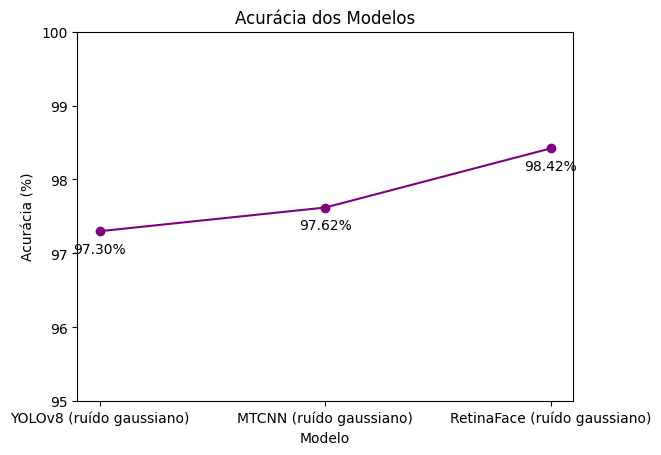

In [ ]:
plt.plot(df_metricas["acuracia"], marker="o", linestyle="-", color="purple")    # Plota uma linha representando a acurácia dos modelos, com marcadores circulares (“o”)
plt.title("Acurácia dos Modelos")                                               # Define o título do gráfico
plt.ylabel("Acurácia (%)")                                                      # Rótulo do eixo Y
plt.xlabel("Modelo")                                                            # Define o rótulo do eixo X
plt.ylim(95, 100)                                                               # Limita o eixo Y entre 95% e 100% para dar mais destaque às diferenças

for i, v in enumerate(df_metricas["acuracia"]):                                 # Adiciona rótulos de texto próximos a cada ponto, mostrando o valor da acurácia
    plt.text(i, v - 0.3, f"{v:.2f}%", ha="center")                              # posiciona o texto levemente abaixo do ponto

plt.show()                                                                      # Exibe o gráfico na tela

**Gráfico em barra de todas as Métricas de avaliação (Acurácia, Precisão, Recall, F1-Score)**

<Figure size 1200x600 with 0 Axes>

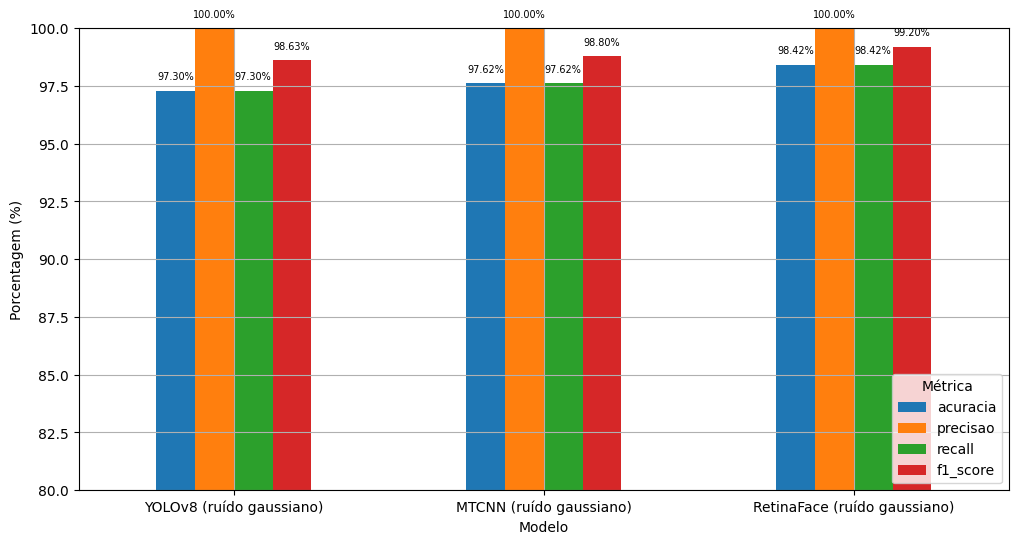

In [ ]:
metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]            # Lista das métricas de desempenho

plt.figure(figsize=(12, 6))                                                     # Cria a figura do gráfico com tamanho definido

ax = df_metricas[metricas_desempenho].plot.bar(                                 # Gera o gráfico de barras a partir do DataFrame; Cada coluna em 'metricas_desempenho' será representada como uma barra
    figsize=(12, 6),
    rot=0,                                                                      # Mantém os rótulos do eixo x na horizontal

    grid=True                                                                   # Ativa a grade para facilitar a visualização
)

for p in ax.patches:                                                            # Adiciona rótulos com os valores numéricos em cima de cada barra
    ax.annotate(f'{p.get_height():.2f}%',                                       # Valor da barra com duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',                                       # Centraliza o texto horizontal e verticalmente
                xytext=(0, 10),                                                 # Desloca o texto 10 pontos acima da barra
                textcoords='offset points',
                fontsize=7)

plt.ylim(80, 100)                                                               # Limita o eixo Y entre 80% e 100%
plt.xlabel("Modelo")                                                            # Define o rótulo do eixo X
plt.ylabel("Porcentagem (%)")                                                   # Define o rótulo do eixo Y
plt.legend(title="Métrica", loc='lower right')                                  # Exibe a legenda com título e posição definida
plt.show()                                                                      # Exibe o gráfico na tela

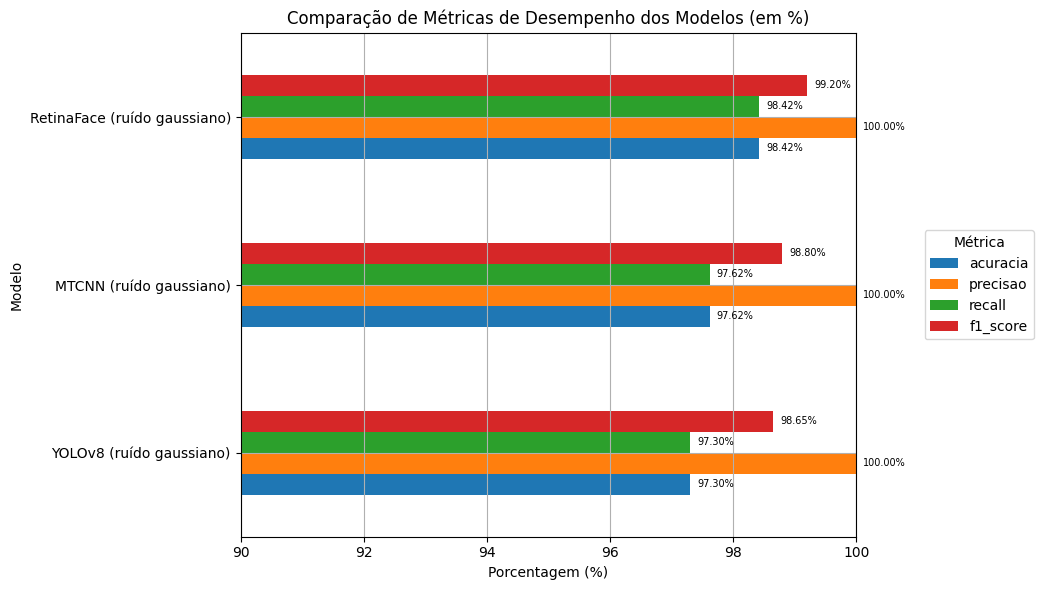

In [33]:
import matplotlib.pyplot as plt

metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]

ax = df_metricas[metricas_desempenho].plot.barh(
    figsize=(12, 6),
    title="Comparação de Métricas de Desempenho dos Modelos (em %)",
    grid=True
)

# Coloca os valores ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7)

plt.xlim(90, 100)
plt.xlabel("Porcentagem (%)")
plt.ylabel("Modelo")

# Legenda na esquerda (fora do gráfico)
ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(left=0.30)  # garante espaço para a legenda
plt.show()


**Gráfico em barra do Tempo médio gerado pelos modelos**

In [ ]:
df_metricas["tempo_medio"] = [0.025, 0.067, 0.173]

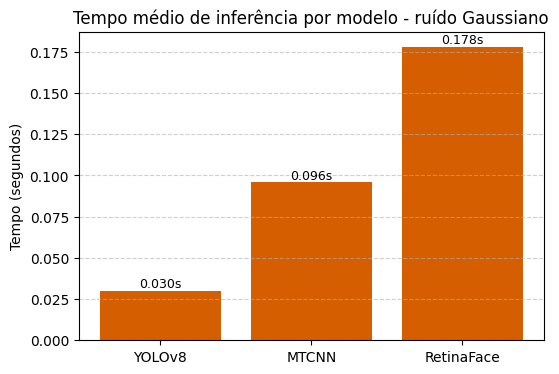

In [ ]:
modelos = ["YOLOv8", "MTCNN", "RetinaFace"]
plt.figure(figsize=(6,4))                                                                    # Cria uma nova figura com tamanho de 6x4 polegadas
plt.bar(modelos, df_metricas["tempo_medio"], color="#D55E00")                       # Plota um gráfico de barras usando o índice do DataFrame como rótulos e a coluna "tempo_medio" como valores de altura das barras
plt.title("Tempo médio de inferência por modelo - ruído Gaussiano")                       # Define o título do gráfico

for i, v in enumerate(df_metricas["tempo_medio"]):
    plt.text(i, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel("Tempo (segundos)")                                                                # Define o rótulo do eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.show()                                                                                    # Exibe o gráfico na tela

**Matrizes de Confusão**

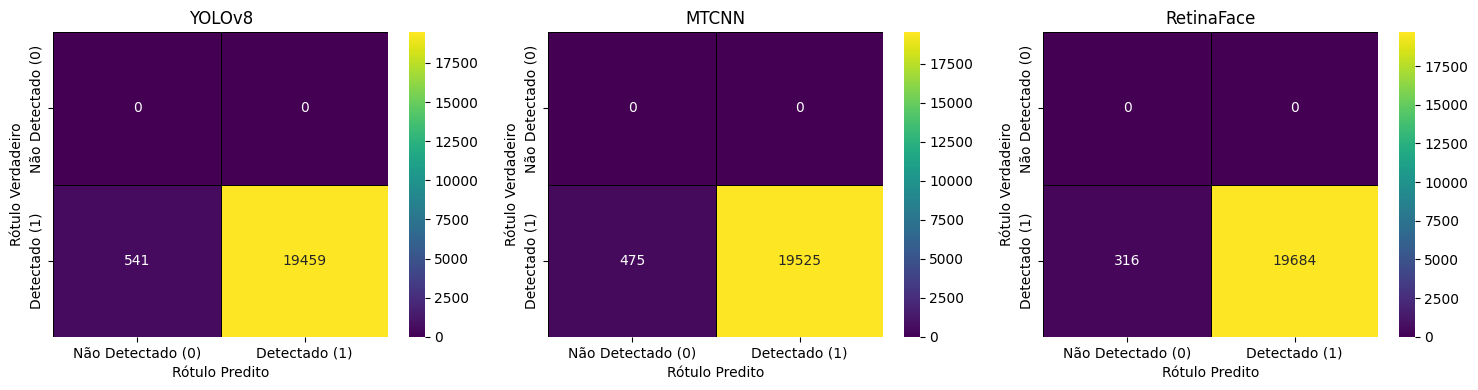

In [ ]:
dados_para_plotar = [                                                           # Lista de tuplas contendo: matrizes de confusão de cada modelo; o nome correspondente do modelo
    (resultados_yolo_ruido_gaussiano, "YOLOv8"),
    (resultados_mtcnn_ruido_gaussiano, "MTCNN"),
    (resultados_retinaface_ruido_gaussiano, "RetinaFace")
]

plotar_matrizes_comparativas(dados_para_plotar)                                 # Geração da Figura com as 3 Matrizes

#**3° avaliação de imagens: ruído Salt & Pepper**

**Aplicando Ruído Salt & Pepper na Base de Dados**

In [ ]:
output_folder = "./dataset_ruido_saltpepper"                                                  # Caminho da pasta onde as imagens com ruído serão salvas
os.makedirs(output_folder, exist_ok=True)                                                     # Cria a pasta caso ela ainda não exista

def adicionar_ruido_salt_pepper(img, prob=0.02):                                              # Função para adicionar ruído Salt & Pepper; prob = proporção de pixels afetados

    if img is None:                                                                           # Caso a imagem não seja lida corretamente, retorna None
        return None

    noisy = np.copy(img)                                                                      # Cria uma cópia da imagem original para modificação
    total_pixels = img.shape[0] * img.shape[1]                                                # Calcula o total de pixels da imagem

    num_salt = int(total_pixels * prob / 2)                                                   # Quantidade de pixels "sal" (brancos)
    num_pepper = int(total_pixels * prob / 2)                                                 # Quantidade de pixels "pimenta" (pretos)

    coords_salt = [np.random.randint(0, i - 1, num_salt) for i in img.shape[:2]]              # Gera coordenadas aleatórias para os pixels brancos
    noisy[coords_salt[0], coords_salt[1]] = 255                                               # Define os pixels selecionados como brancos (255)

    coords_pepper = [np.random.randint(0, i - 1, num_pepper) for i in img.shape[:2]]          # Gera coordenadas aleatórias para os pixels pretos
    noisy[coords_pepper[0], coords_pepper[1]] = 0                                             # Define os pixels selecionados como pretos (0)

    return noisy                                                                              # Retorna a imagem com ruído aplicado

for path in tqdm(all_imgs, desc="Aplicando ruído Salt & Pepper"):                             # Loop principal — aplica o ruído a todas as imagens da lista
    try:
        img = cv2.imread(path)                                                                # Lê a imagem do caminho atual
        img_ruido = adicionar_ruido_salt_pepper(img, prob=0.03)                               # Aplica o ruído Salt & Pepper com probabilidade 3%

        nome_arquivo = os.path.basename(path)                                                 # Extrai apenas o nome do arquivo
        cv2.imwrite(os.path.join(output_folder, nome_arquivo), img_ruido)                     # Salva a imagem ruidosa na pasta alvo
    except Exception as e:                                                                    # Caso ocorra algum erro no processo
        print(f"Erro em {path}: {e}")

# Mensagem final de conclusão; Exibe localização das imagens geradas
print("Ruído Salt & Pepper aplicado com sucesso!")
print(f" Imagens com ruído salvas em: {output_folder}")

imagens_saltpepper = glob.glob('./dataset_ruido_saltpepper/**/*.jpg', recursive=True)         # Lista todas as imagens geradas (inclui subpastas);

# Exibe o total de imagens processadas
print("Total de imagens com ruído Salt & Pepper:", len(imagens_saltpepper))


Aplicando ruído Salt & Pepper: 100%|██████████| 20000/20000 [02:21<00:00, 141.49it/s]


Ruído Salt & Pepper aplicado com sucesso!
 Imagens com ruído salvas em: ./dataset_ruido_saltpepper
Total de imagens com ruído Salt & Pepper: 20000


**Avaliação do Yolov8 na Base da dados com ruído Salt & Pepper**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultados_yolo_ruido_saltpepper, metricas_yolo = avaliar_modelo(imagens_saltpepper, detectar_com_yolo, "YOLOv8 (ruído salt & pepper)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_saltpepper, resultados_yolo_ruido_saltpepper, "YOLOv8 (ruído salt & pepper)")

A saída de streaming foi truncada nas últimas 5000 linhas.
Speed: 2.7ms preprocess, 10.4ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/dataset_ruido_saltpepper/171659.jpg: 640x544 (no detections), 11.4ms
Speed: 2.8ms preprocess, 11.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/dataset_ruido_saltpepper/Mary_Carey_0004.jpg: 640x640 (no detections), 10.0ms
Speed: 4.7ms preprocess, 10.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset_ruido_saltpepper/35_1_1_20170113012820273.jpg: 640x448 (no detections), 9.0ms
Speed: 3.6ms preprocess, 9.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset_ruido_saltpepper/022243.jpg: 640x544 1 knife, 10.1ms
Speed: 2.6ms preprocess, 10.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/dataset_ruido_saltpepper/34_0_1_20170117182640204.jpg: 352x640 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: YOLOv8_(com_ruído_salt_&_pepper)_falhas.zip


**Avaliação do MTCNN na Base da dados com ruído Salt & Pepper**

In [ ]:
# Avalia o modelo MTCNN em todas as imagens, gerando métricas e resultados
resultados_mtcnn_ruido_saltpepper, metricas_mtcnn = avaliar_modelo(imagens_saltpepper, detectar_com_mtcnn, "MTCNN (ruído salt & pepper)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_saltpepper, resultados_mtcnn_ruido_saltpepper, "MTCNN (ruído salt & pepper)")


🔎 Avaliando modelo: MTCNN (com ruído salt & pepper)
===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   98.94%
   Precisão:   100.00%
   Recall:     98.94%
   F1-Score:   99.47%
   ⏱️ Tempo médio: 0.096s

Matriz de Confusão:
[[    0     0]
 [  212 19788]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.99      0.99     20000

    accuracy                           0.99     20000
   macro avg       0.50      0.99      0.50     20000
weighted avg       1.00      0.99      0.99     20000

🚫 212 imagens com falha salvas em: ./falhas/MTCNN_(com_ruído)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: MTCNN_(com_ruído)_falhas.zip


**Avaliação do RetinaFace na Base da dados com ruído alt & Pepper**

In [ ]:
# Avalia o modelo RetinaFace em todas as imagens, gerando métricas e resultados
resultados_retinaface_ruido_saltpepper, metricas_retinaface = avaliar_modelo(imagens_saltpepper, detectar_com_retinaface, "RetinaFace (ruído saltpepper)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_saltpepper, resultados_retinaface_ruido_saltpepper, "RetinaFace (ruído saltpepper)")


🔎 Avaliando modelo: RetinaFace (com ruído saltpepper)


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


25-11-11 02:17:35 - Directory /root/.deepface created
25-11-11 02:17:35 - Directory /root/.deepface/weights created
25-11-11 02:17:35 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:00<00:00, 125MB/s]


===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   92.69%
   Precisão:   100.00%
   Recall:     92.69%
   F1-Score:   96.21%
   ⏱️ Tempo médio: 0.178s

Matriz de Confusão:
[[    0     0]
 [ 1462 18538]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.93      0.96     20000

    accuracy                           0.93     20000
   macro avg       0.50      0.96      0.48     20000
weighted avg       1.00      0.93      0.96     20000

🚫 1462 imagens com falha salvas em: ./falhas/RetinaFace_(com_ruído_saltpepper)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: RetinaFace_(com_ruído_saltpepper)_falhas.zip


**Tabela de resultados com as métricas geradas**

In [20]:
# inserção de dados manuais para o caso de não querer compilar para ver os resultados
dados = {
    "YOLOv8": {
        "acuracia": 65.02,
        "precisao": 100,
        "recall": 65.02,
        "f1_score": 78.80
    },
    "MTCNN": {
        "acuracia": 98.94,
        "precisao": 100,
        "recall": 98.94,
        "f1_score": 99.47
    },
    "RetinaFace": {
        "acuracia": 92.69,
        "precisao": 100,
        "recall": 92.69,
        "f1_score": 96.21
    }
}

df_metricas = pd.DataFrame.from_dict(dados, orient="index")

In [21]:

# # Junta todos os dicionários de métricas em uma lista
# dados = [
#     metricas_yolo,
#     metricas_mtcnn,
#     metricas_retinaface
# ]

# df_metricas = pd.DataFrame(dados)                                                             # Converte em DataFrame
# df_metricas.set_index("modelo", inplace=True)                                                 # Deixa o nome do modelo como índice

for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                                 # Converte para porcentagem (exceto o tempo)
    df_metricas[coluna] = df_metricas[coluna]

display(df_metricas)

,acuracia,precisao,recall,f1_score
YOLOv8,65.02,100,65.02,78.80
MTCNN,98.94,100,98.94,99.47
RetinaFace,92.69,100,92.69,96.21


**Gráfico em barra de Acurácia entre os modelos**

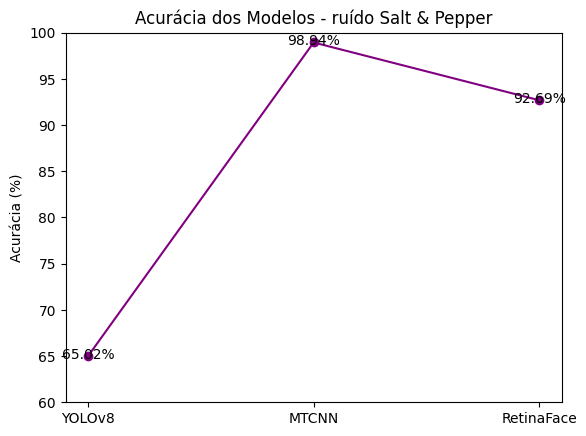

In [ ]:
# Plota uma linha representando a acurácia dos modelos, com marcadores circulares (“o”)
plt.plot(df_metricas["acuracia"], marker="o", linestyle="-", color="purple")
plt.title("Acurácia dos Modelos - ruído Salt & Pepper")                                       # Define o título do gráfico
plt.ylabel("Acurácia (%)")                                                                    # Rótulo do eixo Y
plt.ylim(60, 100)                                                                             # Limita o eixo Y entre 95% e 100% para dar mais destaque às diferenças

# Adiciona rótulos de texto próximos a cada ponto, mostrando o valor da acurácia
for i, v in enumerate(df_metricas["acuracia"]):
    plt.text(i, v - 0.3, f"{v:.2f}%", ha="center")                                            # posiciona o texto levemente abaixo do ponto

plt.show()                                                                                    # Exibe o gráfico na tela

**Gráfico em barra de todas as Métricas de avaliação (Acurácia, Precisão, Recall, F1-Score)**

<Figure size 1200x600 with 0 Axes>

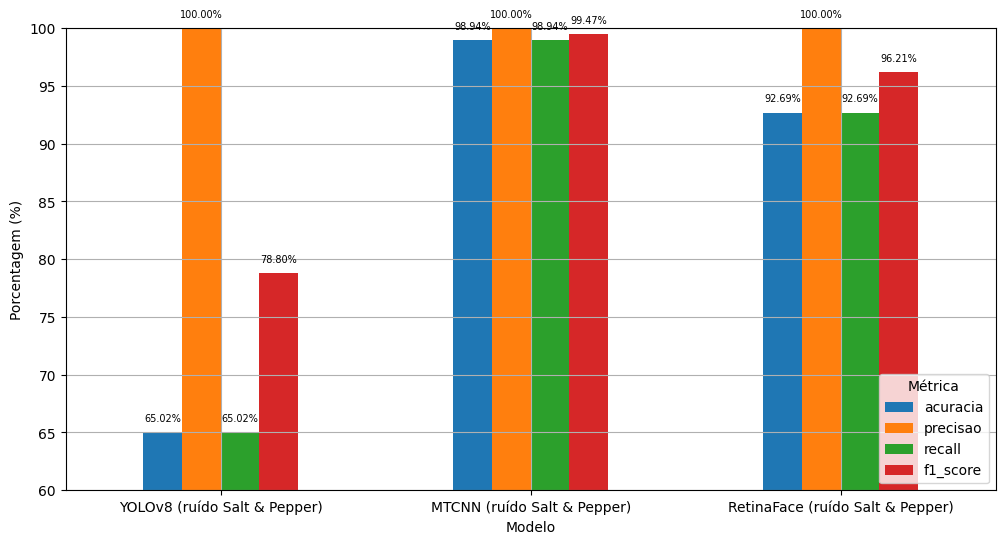

In [ ]:
metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]            # Lista das métricas de desempenho

plt.figure(figsize=(12, 6))                                                     # Cria a figura do gráfico com tamanho definido

ax = df_metricas[metricas_desempenho].plot.bar(                                 # Gera o gráfico de barras a partir do DataFrame; Cada coluna em 'metricas_desempenho' será representada como uma barra
    figsize=(12, 6),
    rot=0,                                                                      # Mantém os rótulos do eixo x na horizontal

    grid=True                                                                   # Ativa a grade para facilitar a visualização
)

for p in ax.patches:                                                            # Adiciona rótulos com os valores numéricos em cima de cada barra
    ax.annotate(f'{p.get_height():.2f}%',                                       # Valor da barra com duas casas decimais
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',                                       # Centraliza o texto horizontal e verticalmente
                xytext=(0, 10),                                                 # Desloca o texto 10 pontos acima da barra
                textcoords='offset points',
                fontsize=7)

plt.ylim(60, 100)                                                               # Limita o eixo Y entre 80% e 100%
plt.xlabel("Modelo")                                                            # Define o rótulo do eixo X
plt.ylabel("Porcentagem (%)")                                                   # Define o rótulo do eixo Y
plt.legend(title="Métrica", loc='lower right')                                  # Exibe a legenda com título e posição definida
plt.show()                                                                      # Exibe o gráfico na tela

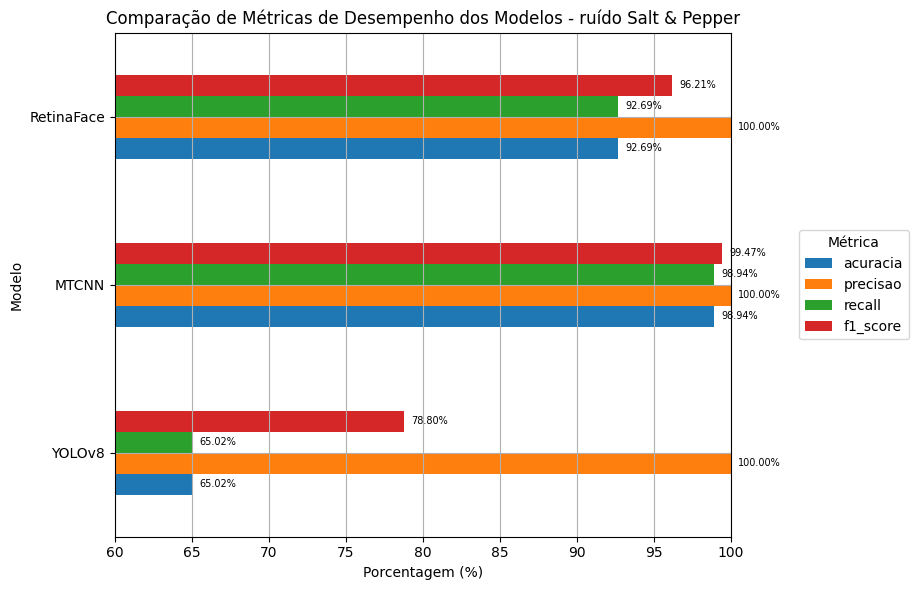

In [23]:
import matplotlib.pyplot as plt

metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]

ax = df_metricas[metricas_desempenho].plot.barh(
    figsize=(12, 6),
    title="Comparação de Métricas de Desempenho dos Modelos - ruído Salt & Pepper",
    grid=True
)

# Coloca os valores ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7)

plt.xlim(60, 100)
plt.xlabel("Porcentagem (%)")
plt.ylabel("Modelo")

# Legenda na esquerda (fora do gráfico)
ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(left=0.30)  # garante espaço para a legenda
plt.show()


**Gráfico em barra do Tempo médio gerado pelos modelos**

In [ ]:
df_metricas["tempo_medio"] = [0.030, 0.096, 0.178]

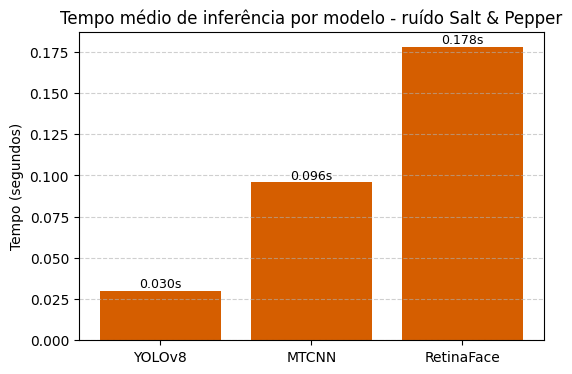

In [ ]:
modelos = ["YOLOv8", "MTCNN", "RetinaFace"]
plt.figure(figsize=(6,4))                                                                    # Cria uma nova figura com tamanho de 6x4 polegadas
plt.bar(modelos, df_metricas["tempo_medio"], color="#D55E00")                       # Plota um gráfico de barras usando o índice do DataFrame como rótulos e a coluna "tempo_medio" como valores de altura das barras
plt.title("Tempo médio de inferência por modelo - ruído Salt & Pepper")                       # Define o título do gráfico

for i, v in enumerate(df_metricas["tempo_medio"]):
    plt.text(i, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel("Tempo (segundos)")                                                                # Define o rótulo do eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.show()                                                                                    # Exibe o gráfico na tela

#**4° avaliação de imagens: ruído Blur**

**Aplicando Ruído Blur na Base de Dados**

In [ ]:
output_folder = "./dataset_ruido_blur"                                                        # Caminho da pasta onde as imagens desfocadas serão salvas
os.makedirs(output_folder, exist_ok=True)                                                     # Cria a pasta caso ela não exista

def aplicar_ruido_blur(img, intensidade=7):                                                   # Função para aplicar ruído Blur; intensidade define o tamanho do kernel

    if img is None:                                                                           # Caso a imagem não seja lida corretamente, retorna None
        return None

    if intensidade % 2 == 0:                                                                  # Garante que o kernel seja ímpar (requisito do GaussianBlur)
        intensidade += 1                                                                      # Ajusta para o próximo número ímpar

    img_blur = cv2.GaussianBlur(img, (intensidade, intensidade), 0)                           # Aplica desfoque gaussiano à imagem
    return img_blur                                                                           # Retorna a imagem desfocada

for path in tqdm(all_imgs, desc="Aplicando ruído Blur"):                                      # Loop principal — aplica Blur a todas as imagens
    try:
        img = cv2.imread(path)                                                                # Lê a imagem do caminho atual
        img_ruido = aplicar_ruido_blur(img, intensidade=9)                                    # Aplica desfoque com kernel 9x9

        nome_arquivo = os.path.basename(path)                                                 # Obtém apenas o nome do arquivo
        cv2.imwrite(os.path.join(output_folder, nome_arquivo), img_ruido)                     # Salva a imagem com Blur na pasta de saída
    except Exception as e:                                                                    # Mostra erro caso algo falhe no processamento
        print(f"Erro em {path}: {e}")

# Mensagem final de conclusão
print(" Ruído Blur aplicado com sucesso!")

# Exibe o caminho onde as imagens foram salvas
print(f" Imagens com ruído salvas em: {output_folder}")

imagens_blur = glob.glob('./dataset_ruido_blur/**/*.jpg', recursive=True)                     # Lista todas as imagens com Blur (incluindo subpastas)

# Mostra quantas imagens foram processadas
print("Total de imagens com ruído Blur:", len(imagens_blur))


Aplicando ruído Blur: 100%|██████████| 20000/20000 [02:46<00:00, 120.19it/s]

 Ruído Blur aplicado com sucesso!
 Imagens com ruído salvas em: ./dataset_ruido_blur
Total de imagens com ruído Blur: 20000


**Avaliação do Yolov8 na Base da dados com ruído Blur**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultados_yolo_ruido_blur, metricas_yolo = avaliar_modelo(imagens_blur, detectar_com_yolo, "YOLOv8 (cruído blur)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_blur, resultados_yolo_ruido_blur, "YOLOv8 (ruído blur)")

A saída de streaming foi truncada nas últimas 5000 linhas.
Speed: 3.3ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/dataset_ruido_blur/2_Demonstration_Political_Rally_2_435.jpg: 640x448 16 persons, 1 cell phone, 8.5ms
Speed: 3.6ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset_ruido_blur/52_Photographers_photographertakingphoto_52_470.jpg: 640x448 1 person, 7.5ms
Speed: 3.6ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset_ruido_blur/Vicente_Fox_0003.jpg: 640x640 1 person, 1 tie, 8.1ms
Speed: 3.0ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset_ruido_blur/30_1_0_20170116211841219.jpg: 640x480 1 person, 7.9ms
Speed: 3.3ms preprocess, 7.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/dataset_ruido_blur

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: YOLOv8_(ruído_blur)_falhas.zip


**Avaliação do MTCNN na Base da dados com ruído Blur**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultados_mtcnn_ruido_blur, metricas_mtcnn = avaliar_modelo(imagens_blur, detectar_com_mtcnn, "MTCNN (ruído blur)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_blur, resultados_mtcnn_ruido_blur, "MTCNN (ruído blur)")


🔎 Avaliando modelo: MTCNN (ruído blur)
===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   97.39%
   Precisão:   100.00%
   Recall:     97.39%
   F1-Score:   98.68%
   ⏱️ Tempo médio: 0.056s

Matriz de Confusão:
[[    0     0]
 [  523 19477]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.97      0.99     20000

    accuracy                           0.97     20000
   macro avg       0.50      0.99      0.49     20000
weighted avg       1.00      0.97      0.99     20000

🚫 523 imagens com falha salvas em: ./falhas/MTCNN_(ruído_blur)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: MTCNN_(ruído_blur)_falhas.zip


**Avaliação do RetinaFace na Base da dados com ruído Blur**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultados_retinaface_ruido_blur, metricas_retinaface = avaliar_modelo(imagens_blur, detectar_com_retinaface, "RetinaFace (ruído blur)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_blur, resultados_retinaface_ruido_blur, "RetinaFace (ruído blur)")


🔎 Avaliando modelo: RetinaFace (ruído blur)
25-11-11 23:56:32 - Directory /root/.deepface created
25-11-11 23:56:32 - Directory /root/.deepface/weights created
25-11-11 23:56:32 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:01<00:00, 93.0MB/s]


===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   98.28%
   Precisão:   100.00%
   Recall:     98.28%
   F1-Score:   99.13%
   ⏱️ Tempo médio: 0.172s

Matriz de Confusão:
[[    0     0]
 [  345 19655]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.98      0.99     20000

    accuracy                           0.98     20000
   macro avg       0.50      0.99      0.50     20000
weighted avg       1.00      0.98      0.99     20000

🚫 345 imagens com falha salvas em: ./falhas/RetinaFace_(ruído_blur)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: RetinaFace_(ruído_blur)_falhas.zip


**Tabela de resultados com as métricas geradas**

In [40]:
# inserção de dados manuais para o caso de não querer compilar para ver os resultados
dados = {
    "YOLOv8": {
        "acuracia": 99.50,
        "precisao": 100,
        "recall": 99.50,
        "f1_score": 99.75
    },
    "MTCNN": {
        "acuracia": 97.39,
        "precisao": 100,
        "recall": 97.39,
        "f1_score": 98.68
    },
    "RetinaFace": {
        "acuracia": 98.28,
        "precisao": 100,
        "recall": 98.28,
        "f1_score": 99.13
    }
}

df_metricas = pd.DataFrame.from_dict(dados, orient="index")


# for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                                 # Converte para porcentagem (exceto o tempo)
#     df_metricas[coluna] = df_metricas[coluna]

# display(df_metricas)

In [41]:
# # Junta todos os dicionários de métricas em uma lista
# dados = [
#     metricas_yolo,
#     metricas_mtcnn,
#     metricas_retinaface
# ]

# Converte em DataFrame
# df_metricas = pd.DataFrame(dados)

# Deixa o nome do modelo como índice
# df_metricas.set_index("modelo", inplace=True)

# Converte para porcentagem (exceto o tempo)
for coluna in ["acuracia", "precisao", "recall", "f1_score"]:
    df_metricas[coluna] = df_metricas[coluna]

# Exibe a tabela no Colab
display(df_metricas)

,acuracia,precisao,recall,f1_score
YOLOv8,99.50,100,99.50,99.75
MTCNN,97.39,100,97.39,98.68
RetinaFace,98.28,100,98.28,99.13


**Gráfico em barra de Acurácia entre os modelos**

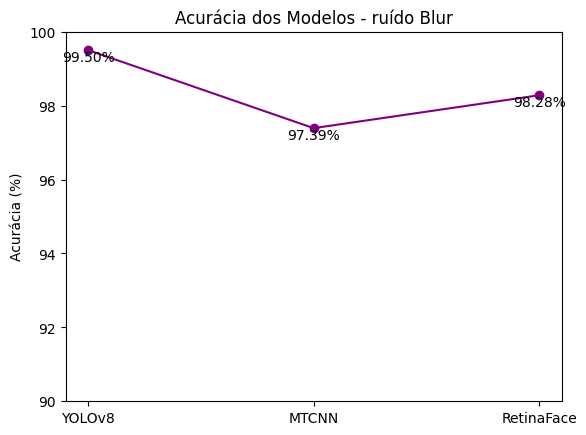

In [ ]:
# Plota uma linha representando a acurácia dos modelos, com marcadores circulares (“o”)
plt.plot(df_metricas["acuracia"], marker="o", linestyle="-", color="purple")
plt.title("Acurácia dos Modelos - ruído Blur")                                                # Define o título do gráfico
plt.ylabel("Acurácia (%)")                                                                    # Rótulo do eixo Y
plt.ylim(90, 100)                                                                             # Limita o eixo Y entre 95% e 100% para dar mais destaque às diferenças

# Adiciona rótulos de texto próximos a cada ponto, mostrando o valor da acurácia
for i, v in enumerate(df_metricas["acuracia"]):
    plt.text(i, v - 0.3, f"{v:.2f}%", ha="center")                                            # posiciona o texto levemente abaixo do ponto

plt.show()                                                                                    # Exibe o gráfico na tela

**Gráfico em barra de todas as Métricas de avaliação (Acurácia, Precisão, Recall, F1-Score)**

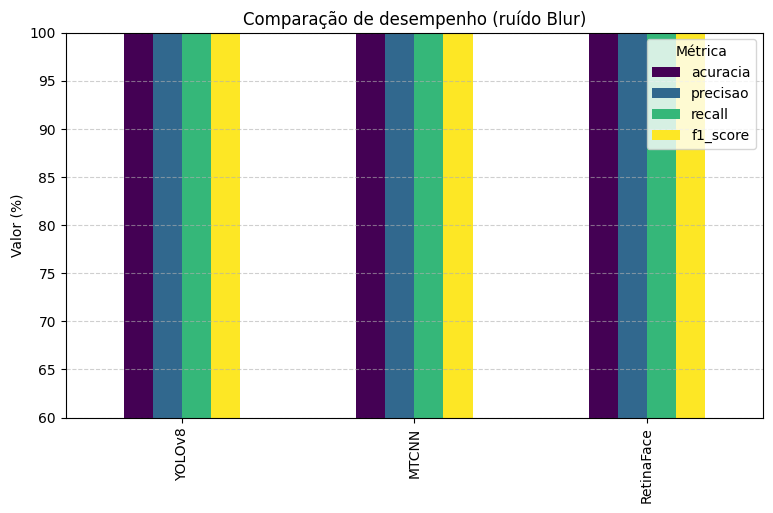

In [30]:
# Plota um gráfico de barras usando as métricas acurácia, precisão, recall e F1 Score
df_metricas[["acuracia", "precisao", "recall", "f1_score"]].plot(
    kind='bar',                                                                               # Define o tipo de gráfico como barras
    figsize=(9,5),                                                                            # Define o tamanho da figura
    colormap='viridis'                                                                        # Define o mapa de cores usado para as barras
)

plt.title("Comparação de desempenho (ruído Blur)")                                            # Define o título do gráfico
plt.ylabel("Valor (%)")                                                                       # Define o rótulo do eixo Y
plt.ylim(60, 100)                                                                             # Ajusta o limite do eixo Y para focar nos valores acima de 90%
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura do gráfico
plt.legend(title="Métrica")                                                                   # Exibe a legenda com o título "Métrica"
plt.show()                                                                                    # Mostra o gráfico na tela

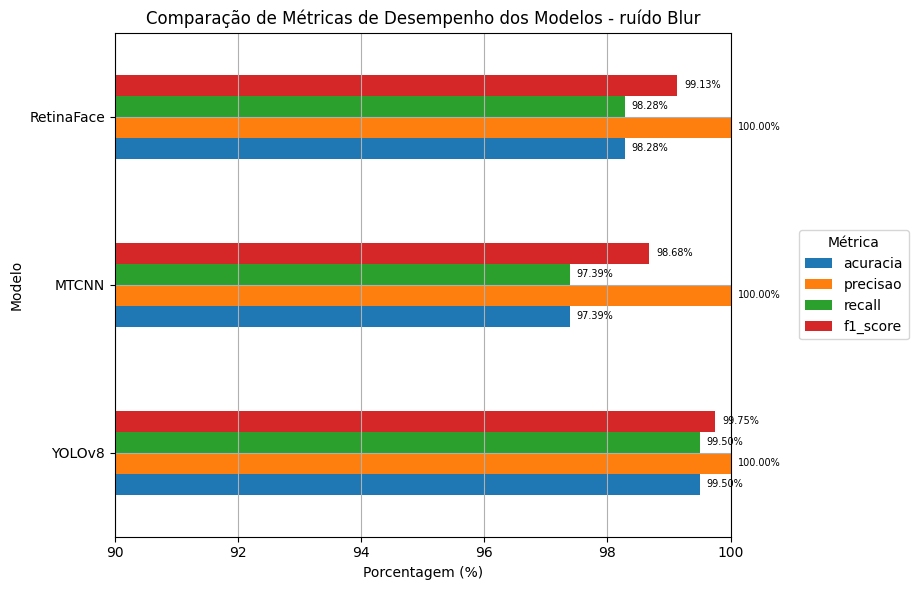

In [42]:
import matplotlib.pyplot as plt

metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]

ax = df_metricas[metricas_desempenho].plot.barh(
    figsize=(12, 6),
    title="Comparação de Métricas de Desempenho dos Modelos - ruído Blur",
    grid=True
)

# Coloca os valores ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7)

plt.xlim(90, 100)
plt.xlabel("Porcentagem (%)")
plt.ylabel("Modelo")

# Legenda na esquerda (fora do gráfico)
ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(left=0.30)  # garante espaço para a legenda
plt.show()


**Gráfico em barra do Tempo médio gerado pelos modelos**

In [ ]:
df_metricas["tempo_medio"] = [0.023, 0.056, 0.172]

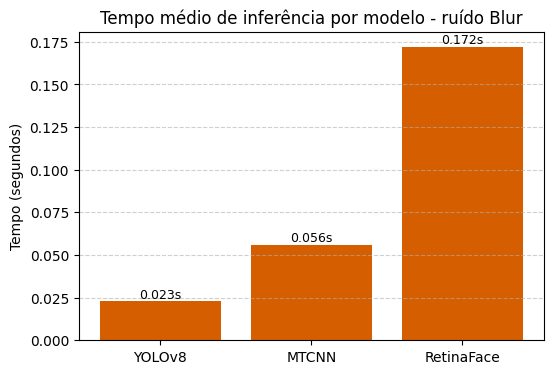

In [ ]:
modelos = ["YOLOv8", "MTCNN", "RetinaFace"]
plt.figure(figsize=(6,4))                                                                    # Cria uma nova figura com tamanho de 6x4 polegadas
plt.bar(modelos, df_metricas["tempo_medio"], color="#D55E00")                       # Plota um gráfico de barras usando o índice do DataFrame como rótulos e a coluna "tempo_medio" como valores de altura das barras
plt.title("Tempo médio de inferência por modelo - ruído Blur")                       # Define o título do gráfico

for i, v in enumerate(df_metricas["tempo_medio"]):
    plt.text(i, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel("Tempo (segundos)")                                                                # Define o rótulo do eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.show()                                                                                    # Exibe o gráfico na tela


# **5° avaliação de imagens: ruído Compressed**


**Aplicando Ruído Compressed na Base de Dados**

In [ ]:
output_folder = "./dataset_ruido_compressed"                                                  # Caminho da pasta onde as imagens comprimidas serão salvas
os.makedirs(output_folder, exist_ok=True)                                                     # Cria a pasta caso ainda não exista

def aplicar_ruido_compressed(img, qualidade=20):                                              # Função para aplicar ruído de compressão JPEG; qualidade baixa = mais ruído

    if img is None:                                                                           # Verifica se a imagem foi lida corretamente
        return None

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), qualidade]                                 # Parâmetro que define a qualidade da compressão JPEG
    _, buffer = cv2.imencode(".jpg", img, encode_param)                                       # Codifica a imagem em memória com a qualidade desejada
    img_ruido = cv2.imdecode(buffer, cv2.IMREAD_COLOR)                                        # Decodifica, aplicando assim o ruído de compressão
    return img_ruido                                                                           # Retorna a imagem comprimida

for path in tqdm(all_imgs, desc="Aplicando ruído Compressed"):                                # Loop principal — aplica compressão em todas as imagens
    try:
        img = cv2.imread(path)                                                                # Lê a imagem original
        img_ruido = aplicar_ruido_compressed(img, qualidade=10)                               # Aplica compressão com qualidade 10 (alto ruído)

        if img_ruido is not None:                                                             # Garante que a compressão funcionou
            nome_arquivo = os.path.basename(path)                                             # Extrai apenas o nome do arquivo
            cv2.imwrite(os.path.join(output_folder, nome_arquivo), img_ruido)                 # Salva a imagem comprimida
    except Exception as e:                                                                    # Em caso de erro, mostra o arquivo problemático
        print(f"⚠️ Erro em {path}: {e}")

# Mensagem final de conclusão
print("Ruído Compressed aplicado com sucesso!")

# Caminho das imagens comprimidas
print(f"Imagens com ruído salvas em: {output_folder}")

imagens_compressed = glob.glob('./dataset_ruido_compressed/**/*.jpg', recursive=True)         # Lista todas as imagens com ruído de compressão

# Exibe o total de imagens geradas
print("Total de imagens com ruído Compressed:", len(imagens_compressed))


Aplicando ruído Compressed: 100%|██████████| 20000/20000 [02:02<00:00, 162.85it/s]

Ruído Compressed aplicado com sucesso!
Imagens com ruído salvas em: ./dataset_ruido_compressed
Total de imagens com ruído Compressed: 20000


**Avaliação do Yolov8 na Base da dados com ruído Compressed**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultaods_yolo_ruido_compressed, metricas_yolo = avaliar_modelo(imagens_compressed, detectar_com_yolo, "YOLOv8 (ruído compressed)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_compressed, resultaods_yolo_ruido_compressed, "YOLOv8 (ruído compressed)")


A saída de streaming foi truncada nas últimas 5000 linhas.
Speed: 3.3ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/dataset_ruido_compressed/2_Demonstration_Political_Rally_2_435.jpg: 640x448 8 persons, 8.4ms
Speed: 3.5ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset_ruido_compressed/52_Photographers_photographertakingphoto_52_470.jpg: 640x448 (no detections), 7.8ms
Speed: 3.7ms preprocess, 7.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset_ruido_compressed/Vicente_Fox_0003.jpg: 640x640 1 person, 9.4ms
Speed: 3.3ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset_ruido_compressed/30_1_0_20170116211841219.jpg: 640x480 (no detections), 8.1ms
Speed: 3.2ms preprocess, 8.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/da

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: YOLOv8_(ruído_compressed)_falhas.zip


**Avaliação do MTCNN na Base da dados com ruído Compressed**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultaods_mtcnn_ruido_compressed, metricas_mtcnn = avaliar_modelo(imagens_compressed, detectar_com_mtcnn, "MTCNN (ruído compressed)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_compressed, resultaods_mtcnn_ruido_compressed, "MTCNN (ruído compressed)")


🔎 Avaliando modelo: MTCNN (ruído compressed)
===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   97.39%
   Precisão:   100.00%
   Recall:     97.39%
   F1-Score:   98.68%
   ⏱️ Tempo médio: 0.069s

Matriz de Confusão:
[[    0     0]
 [  521 19479]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.97      0.99     20000

    accuracy                           0.97     20000
   macro avg       0.50      0.99      0.49     20000
weighted avg       1.00      0.97      0.99     20000

🚫 521 imagens com falha salvas em: ./falhas/MTCNN_(ruído_compressed)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: MTCNN_(ruído_compressed)_falhas.zip


**Avaliação do RetinaFace na Base da dados com ruído Compressed**

In [ ]:
# Avalia o modelo Yolov8 em todas as imagens, gerando métricas e resultados
resultaods_retinaface_ruido_compressed, metricas_retinaface = avaliar_modelo(imagens_compressed, detectar_com_retinaface, "RetinaFace (ruído compressed)")

# Identifica e salva automaticamente as imagens em que o modelo não detectou nenhum rosto
salvar_imagens_falhas(imagens_compressed, resultaods_retinaface_ruido_compressed, "RetinaFace (ruído compressed)")


🔎 Avaliando modelo: RetinaFace (ruído compressed)
25-11-12 01:51:13 - Directory /root/.deepface created
25-11-12 01:51:13 - Directory /root/.deepface/weights created
25-11-12 01:51:13 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:01<00:00, 64.5MB/s]


===== MÉTRICAS DE AVALIAÇÃO =====
   Acurácia:   95.56%
   Precisão:   100.00%
   Recall:     95.56%
   F1-Score:   97.73%
   ⏱️ Tempo médio: 0.175s

Matriz de Confusão:
[[    0     0]
 [  889 19111]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.96      0.98     20000

    accuracy                           0.96     20000
   macro avg       0.50      0.98      0.49     20000
weighted avg       1.00      0.96      0.98     20000

🚫 889 imagens com falha salvas em: ./falhas/RetinaFace_(ruído_compressed)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 ZIP gerado: RetinaFace_(ruído_compressed)_falhas.zip


**Tabela de resultados com as métricas geradas**

In [43]:
# inserção de dados manuais para o caso de não querer compilar para ver os resultados
dados = {
    "YOLOv8": {
        "acuracia": 40.27,
        "precisao": 100,
        "recall": 40.27,
        "f1_score": 57.42
    },
    "MTCNN": {
        "acuracia": 97.39,
        "precisao": 100,
        "recall": 97.39,
        "f1_score": 98.68
    },
    "RetinaFace": {
        "acuracia": 95.56,
        "precisao": 100,
        "recall": 95.56,
        "f1_score": 97.73
    }
}

df_metricas = pd.DataFrame.from_dict(dados, orient="index")

for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                                 # Converte para porcentagem (exceto o tempo)
    df_metricas[coluna] = df_metricas[coluna]

display(df_metricas)

,acuracia,precisao,recall,f1_score
YOLOv8,40.27,100,40.27,57.42
MTCNN,97.39,100,97.39,98.68
RetinaFace,95.56,100,95.56,97.73


In [ ]:
# Junta todos os dicionários de métricas em uma lista
dados = [
    metricas_yolo,
    metricas_mtcnn,
    metricas_retinaface
]

df_metricas = pd.DataFrame(dados)                                                             # Converte em DataFrame
df_metricas.set_index("modelo", inplace=True)                                                 # Deixa o nome do modelo como índice

for coluna in ["acuracia", "precisao", "recall", "f1_score"]:                                 # Converte para porcentagem (exceto o tempo)
    df_metricas[coluna] = df_metricas[coluna] * 100

display(df_metricas)

,acuracia,precisao,recall,f1_score,tempo_medio
modelo,,,,,
YOLOv8 (ruído compressed),40.275,100.0,40.275,57.422919,0.018658
MTCNN (ruído compressed),97.395,100.0,97.395,98.680311,0.069354
RetinaFace (ruído compressed),95.555,100.0,95.555,97.726982,0.174584


**Gráfico em barra de Acurácia entre os modelos**

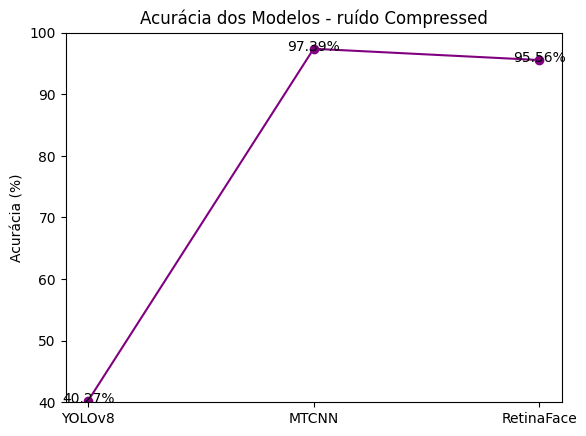

In [ ]:
# Plota uma linha representando a acurácia dos modelos, com marcadores circulares (“o”)
plt.plot(df_metricas["acuracia"], marker="o", linestyle="-", color="purple")
plt.title("Acurácia dos Modelos - ruído Compressed")                                          # Define o título do gráfico
plt.ylabel("Acurácia (%)")                                                                    # Rótulo do eixo Y
plt.ylim(40, 100)                                                                             # Limita o eixo Y entre 95% e 100% para dar mais destaque às diferenças

# Adiciona rótulos de texto próximos a cada ponto, mostrando o valor da acurácia
for i, v in enumerate(df_metricas["acuracia"]):
    plt.text(i, v - 0.3, f"{v:.2f}%", ha="center")                                            # posiciona o texto levemente abaixo do ponto

plt.show()                                                                                    # Exibe o gráfico na tela

**Gráfico em barra de todas as Métricas de avaliação (Acurácia, Precisão, Recall, F1-Score)**

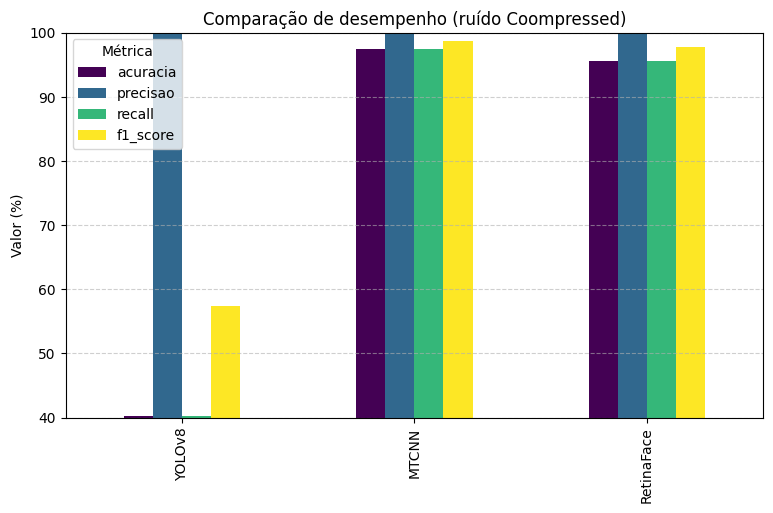

In [37]:
# Plota um gráfico de barras usando as métricas acurácia, precisão, recall e F1 Score
df_metricas[["acuracia", "precisao", "recall", "f1_score"]].plot(
    kind='bar',                                                                               # Define o tipo de gráfico como barras
    figsize=(9,5),                                                                            # Define o tamanho da figura
    colormap='viridis'                                                                        # Define o mapa de cores usado para as barras
)

plt.title("Comparação de desempenho (ruído Coompressed)")                                     # Define o título do gráfico
plt.ylabel("Valor (%)")                                                                       # Define o rótulo do eixo Y
plt.ylim(40, 100)                                                                             # Ajusta o limite do eixo Y para focar nos valores acima de 90%
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura do gráfico
plt.legend(title="Métrica")                                                                   # Exibe a legenda com o título "Métrica"
plt.show()                                                                                    # Mostra o gráfico na tela

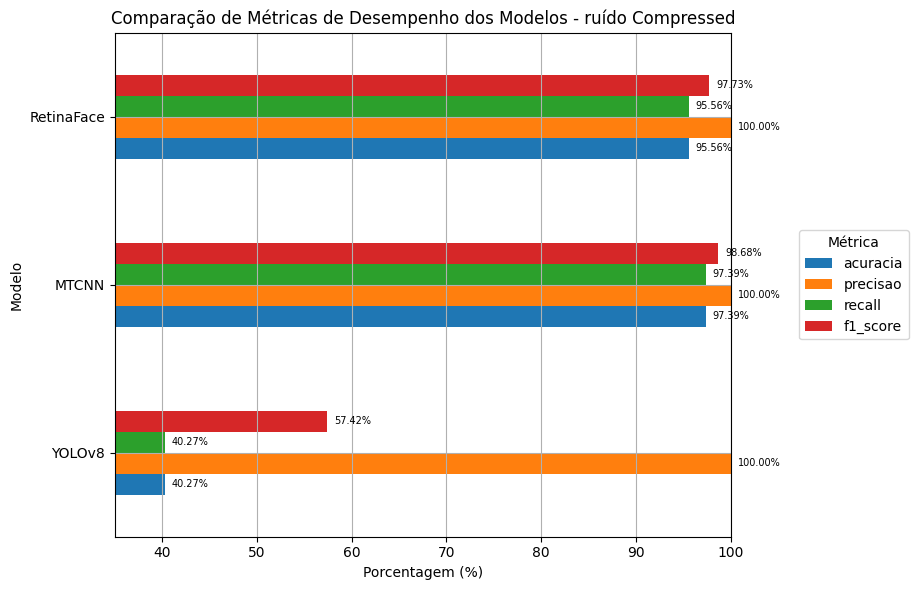

In [44]:
import matplotlib.pyplot as plt

metricas_desempenho = ["acuracia", "precisao", "recall", "f1_score"]

ax = df_metricas[metricas_desempenho].plot.barh(
    figsize=(12, 6),
    title="Comparação de Métricas de Desempenho dos Modelos - ruído Compressed",
    grid=True
)

# Coloca os valores ao lado das barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=7)

plt.xlim(35, 100)
plt.xlabel("Porcentagem (%)")
plt.ylabel("Modelo")

# Legenda na esquerda (fora do gráfico)
ax.legend(
    title="Métrica",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.subplots_adjust(left=0.30)  # garante espaço para a legenda
plt.show()


**Gráfico em barra do Tempo médio gerado pelos modelos**

In [ ]:
df_metricas["tempo_medio"] = [0.019, 0.069, 0.175]

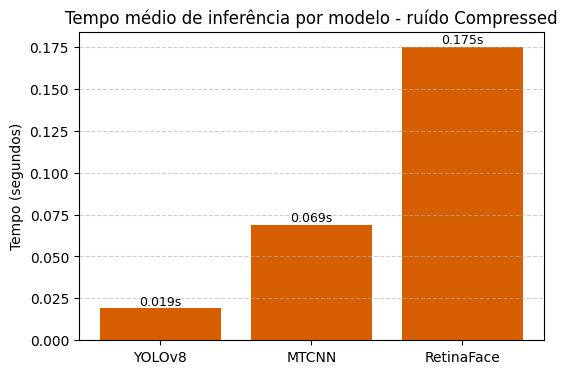

In [ ]:
modelos = ["YOLOv8", "MTCNN", "RetinaFace"]
plt.figure(figsize=(6,4))                                                                    # Cria uma nova figura com tamanho de 6x4 polegadas
plt.bar(modelos, df_metricas["tempo_medio"], color="#D55E00")                       # Plota um gráfico de barras usando o índice do DataFrame como rótulos e a coluna "tempo_medio" como valores de altura das barras
plt.title("Tempo médio de inferência por modelo - ruído Compressed")                       # Define o título do gráfico

for i, v in enumerate(df_metricas["tempo_medio"]):
    plt.text(i, v, f"{v:.3f}s", ha='center', va='bottom', fontsize=9)

plt.ylabel("Tempo (segundos)")                                                                # Define o rótulo do eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.6)                                                 # Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.show()                                                                                    # Exibe o gráfico na tela